In [ ]:
from CHIMERA.cosmo import flrw
from CHIMERA.mass import plp
from CHIMERA.rate import madau_dickinson
from CHIMERA.catalog import dVdz_completeness, pixelated_catalog, mask_completeness
from CHIMERA import population, compute_z_grids
from CHIMERA import data as data
import h5py
import numpy as np
import jax.numpy as jnp
from astropy.cosmology import FlatLambdaCDM
from CHIMERA import utils
import healpy as hp

"""GW data"""
fpe = "./data/PE_O5Like_snr20.h5"
f_gw_pix = './data/PE_O5Like_snr20_pixelated_nsidelist512-256-128-64-32-16-8_meanpixels15_skyconf0.9_nestFalse.h5'
gw_pe_det_pixelated = data.load_pixelated_gw_catalog(f_gw_pix)

"""fiducial cosmology"""
cosmo = flrw(
            H0 = 70., 
            Om0=0.25,
            z_max = 5.
            )

z_grids = compute_z_grids(cosmo, 
                          gw_pe_det_pixelated, 
                          cosmo_prior = {'H0':[20,200]}, 
                          z_int_res = 500,)

"""galaxy catalog"""
fname_gal = "./data/parent_galaxy_catalog_1.6M_dVdz.h5"

mask_str = 'cosmos_subaru_b_true'
photo_thresholds = 24
spec_default_thresholds = 19.5
spec_subaru_thresholds = 22
with h5py.File(fname_gal, "r") as f:
    mask_photo = f[mask_str][:]<=photo_thresholds
    mask_spec_default = f[mask_str][:]<=spec_default_thresholds
    mask_spec_subaru = f[mask_str][:]<=spec_subaru_thresholds

    z_gal = f['z_cgal'][:]
    
    ra_gal_raw = f['ra_gal'][:]
    dec_gal_raw = f['dec_gal'][:]
    
    phi_gal = np.radians(ra_gal_raw)
    theta_gal = np.radians(90.0 - dec_gal_raw)
    
    ra_gal_deg = (ra_gal_raw + 180) % 360 - 180
    dec_gal_deg = dec_gal_raw
    ra_gal_rad = np.deg2rad(ra_gal_deg)
    dec_gal_rad = np.deg2rad(dec_gal_deg)
print(f"\nMask applied with threshold {photo_thresholds} on {mask_str}. Number of galaxies after masking: {np.sum(mask_photo)}")

photo_err = 0.05
spec_err = 0.001

"""select follow up event"""
gw_opt_nsides = gw_pe_det_pixelated.opt_nsides
gw_pixels_opt_nsides = gw_pe_det_pixelated.pixels_opt_nsides
# print(f"GW pixelated catalog loaded with NSIDE values: {gw_opt_nsides}")
# print(f"GW pixelated catalog loaded with pixelated NSIDE values: {gw_pixels_opt_nsides}")

GW_properties = utils.io.load_data_h5(fpe, group_h5='properties')
gw_sky_area = GW_properties['sky_area']
gw_snr = GW_properties['snr']

num_follow_up_events_list = [0, 10, 50, 100]
z_err_array_list = []
for num_follow_up_events in num_follow_up_events_list:
    print(f"\nSelecting top {num_follow_up_events} GW events for follow-up based on sky area.")
    
    z_err_array = np.zeros_like(z_gal)
    z_err_array[mask_photo] = photo_err
    z_err_array[mask_spec_default] = spec_err

    is_in_gw_area_total = np.zeros_like(z_gal, dtype=bool)
    if num_follow_up_events > 0:
        best_sky_area_indices = np.argsort(gw_sky_area)[:num_follow_up_events]
        target_gw_indices = best_sky_area_indices

        ev_nsides_array = gw_opt_nsides[target_gw_indices]
        ev_pixels_array = gw_pixels_opt_nsides[target_gw_indices]

        for idx, (nside, pixels) in enumerate(zip(ev_nsides_array, ev_pixels_array)):
            valid_pixels = pixels[pixels >= 0]
            gal_pixel_ids = hp.ang2pix(nside, theta_gal, phi_gal, nest=False)
            is_in_gw_area_total |= np.isin(gal_pixel_ids, valid_pixels)
            # print(f"GW event {target_gw_indices[idx]}: {np.sum(is_in_gw_area_total)} galaxies to spec-z with error {spec_err}.")

        z_err_array[is_in_gw_area_total & mask_spec_subaru] = spec_err
    z_err_array_list.append(z_err_array)
    print(f"Total galaxies with spec-z error {spec_err} and {spec_default_thresholds} < r < {spec_subaru_thresholds}: {np.sum(is_in_gw_area_total & mask_spec_subaru)}")
    print(f"Total galaxies with spec-z error {spec_err} and r < {spec_default_thresholds}: {np.sum(mask_spec_default)}")
    print(f"Total galaxies with photo-z error {photo_err}: {np.sum(z_err_array == photo_err)}")
    print(f"Total sky area covered by top {num_follow_up_events} GW events: {np.sum(gw_sky_area[target_gw_indices]) if num_follow_up_events > 0 else 0} deg^2")

"""calculate number density for completeness"""
cosmo_astropy = FlatLambdaCDM(H0=cosmo.H0, Om0=cosmo.Om0)  # 必要に応じて変更してください
sky_area_deg2 = 5170.26
f_sky = sky_area_deg2 / 41252.9614  # 全天に対する割合 (約 0.125)
z_min, z_max = 0.073, 1.3
N_gal = np.sum((z_gal >= z_min) & (z_gal < z_max))
V_min = cosmo_astropy.comoving_volume(z_min).value
V_max = cosmo_astropy.comoving_volume(z_max).value
V_shell = (V_max - V_min) * f_sky
true_density = N_gal / V_shell
print(f"\nCalculated true density: {true_density:.5f} Mpc^-3")

def my_n_gal_theo(z):
    return jnp.ones_like(z) * true_density

"""compileteness setting"""
completeness_photo = mask_completeness(
    cosmo_lambdas=cosmo,
    n_gal_theo=my_n_gal_theo,
    z_gal=z_gal,
    ra_gal=ra_gal_rad,
    dec_gal=dec_gal_rad,
    mask_and_gal=mask_photo,
    z_int_range=[0.073, 1.3]
)

"""pixelated catalog"""
gal_cat_list = []
population_list = []
mass = plp()
rate = madau_dickinson(gamma = 2.7,
                       kappa =  3.,
                       zp = 2.)
for num_events, z_err_array in zip(num_follow_up_events_list, z_err_array_list):

    gal_cat = pixelated_catalog(completeness_photo, 
                                gal_cat_file = f'./data/galcat_subaru_sky_area_{num_events}.h5',
                                # if the argument above is None it is necessary to specify the argument below to compute p_cat
                                data_gw_pixelated = gw_pe_det_pixelated, 
                                # cosmo = cosmo,
                                # z_grids = z_grids, 
                                # fname_data_gal = fname_gal, 
                                # z_err = z_err_array,
                                # out_file = f'./data/galcat_subaru_sky_area_{num_events}.h5',
                                # mask_gal = mask_photo
                                )

    gal_cat_list.append(gal_cat)

    population_function = population(cosmo, mass, rate, gal_cat=gal_cat, scale_free=True)
    population_list.append(population_function)

2026-06-09 21:37:46,929 - CHIMERA - INFO - Loading `CHIMERA`. GPU acceleration: False



Mask applied with threshold 24 on cosmos_subaru_b_true. Number of galaxies after masking: 381805

Selecting top 0 GW events for follow-up based on sky area.
Total galaxies with spec-z error 0.001 and 19.5 < r < 22: 0
Total galaxies with spec-z error 0.001 and r < 19.5: 2016
Total galaxies with photo-z error 0.05: 379789
Total sky area covered by top 0 GW events: 0 deg^2

Selecting top 10 GW events for follow-up based on sky area.
Total galaxies with spec-z error 0.001 and 19.5 < r < 22: 53
Total galaxies with spec-z error 0.001 and r < 19.5: 2016
Total galaxies with photo-z error 0.05: 379740
Total sky area covered by top 10 GW events: 3.8454696328980704 deg^2

Selecting top 50 GW events for follow-up based on sky area.
Total galaxies with spec-z error 0.001 and 19.5 < r < 22: 454
Total galaxies with spec-z error 0.001 and r < 19.5: 2016
Total galaxies with photo-z error 0.05: 379366
Total sky area covered by top 50 GW events: 54.44850692743498 deg^2

Selecting top 100 GW events for f

2026-06-09 21:37:59,991 - CHIMERA - INFO - Initializing `masked_completeness`:


Total galaxies with spec-z error 0.001 and 19.5 < r < 22: 1240
Total galaxies with spec-z error 0.001 and r < 19.5: 2016
Total galaxies with photo-z error 0.05: 378624
Total sky area covered by top 100 GW events: 173.84006237488762 deg^2

Calculated true density: 0.00004 Mpc^-3


2026-06-09 21:38:01,617 - CHIMERA - INFO - Loading gal_cat object from ./data/galcat_subaru_sky_area_0.h5
2026-06-09 21:38:01,661 - CHIMERA - INFO - Setting up the completeness mask indices from loaded GW data
/Users/hayato/research/env/lib/python3.10/site-packages/healpy/pixelfunc.py:529: RuntimeWarning: divide by zero encountered in _pix2ang_ring
  theta, phi = pixlib._pix2ang_ring(nside, ipix)
/Users/hayato/research/env/lib/python3.10/site-packages/healpy/pixelfunc.py:529: RuntimeWarning: invalid value encountered in _pix2ang_ring
  theta, phi = pixlib._pix2ang_ring(nside, ipix)
/Users/hayato/research/env/lib/python3.10/site-packages/healpy/pixelfunc.py:482: RuntimeWarning: invalid value encountered in _ang2pix_ring
  return pixlib._ang2pix_ring(nside, theta, phi)
2026-06-09 21:38:02,984 - CHIMERA - INFO - Loading gal_cat object from ./data/galcat_subaru_sky_area_10.h5
2026-06-09 21:38:03,022 - CHIMERA - INFO - Setting up the completeness mask indices from loaded GW data
/Users/haya

False
True
False
True
False
True
False
True


In [2]:
from CHIMERA import selection_function
from CHIMERA.utils.config import jax, jnp
from tqdm import tqdm 

file_inj = "./data/injections_Ninj_2e7_O5Like_snr20.h5"
gw_inj_data = data.load_injection_data(file_inj, snr_cut=20, return_struct = True)
# inj_prior *= 1000 needed for LVK injection drawn from \pi_{draw} in which ddL/dz is in Mpc instead of Gpc

sel_fcn = selection_function(gw_inj_data, N_inj=20*1e6)

In [3]:
from CHIMERA import hyperlikelihood

like_jax_list = []

for pop_func in population_list:
    like_jax = hyperlikelihood(  
        gw_pe_det_pixelated, # data
        z_grids, # z_grids
        population=pop_func, # pop model
        selection_function=sel_fcn, # bias model
        kind_p_gw3d = 'marginalized', # KDE settings 'full', 'approximated'
        kernel='epan', # 'epan'
        bw_method=None,
        cut_grid=2,
        binning=True,
        num_bins=200,
        )
    like_jax_list.append(like_jax)

2026-06-09 21:50:56,782 - CHIMERA - INFO - Created hyperlikelihood model. Using 300 GW events.
2026-06-09 21:50:56,782 - CHIMERA - INFO - Created hyperlikelihood model. Using 300 GW events.
2026-06-09 21:50:56,783 - CHIMERA - INFO - Created hyperlikelihood model. Using 300 GW events.
2026-06-09 21:50:56,783 - CHIMERA - INFO - Created hyperlikelihood model. Using 300 GW events.


In [4]:
import numpy as np
import jax.numpy as jnp
import tqdm

# H0 = jnp.linspace(20, 200, 100)
H0 = jnp.linspace(60, 90, 100)
# res_H0 = np.zeros((H0.shape[0], like_jax.z_int_res))

H0 = jnp.linspace(60, 90, 100)

res_H0_list = [np.zeros_like(H0) for _ in range(len(like_jax_list))]

for i, h0 in tqdm.tqdm(enumerate(H0), total=len(H0)):
    for j, like_jax in enumerate(like_jax_list):
        res = like_jax(H0=h0)
        res_H0_list[j][i] = jnp.sum(res)

post_jax_list = []
for res_H0 in res_H0_list:
    post_jax = res_H0.copy()
    post_jax -= np.nanmax(post_jax)
    post_jax = np.exp(post_jax)
    post_jax /= np.trapz(post_jax, H0)
    
    post_jax_list.append(post_jax)

100%|██████████| 100/100 [03:12<00:00,  1.93s/it]



area of 0: 1.0
Fractional error of 0: 0.028893485470482913

area of 10: 1.0000000000000002
Fractional error of 10: 0.01769793008339244

area of 50: 0.9999999999999998
Fractional error of 50: 0.014267321996760582

area of 100: 0.9999999999999998
Fractional error of 100: 0.013687969692141293


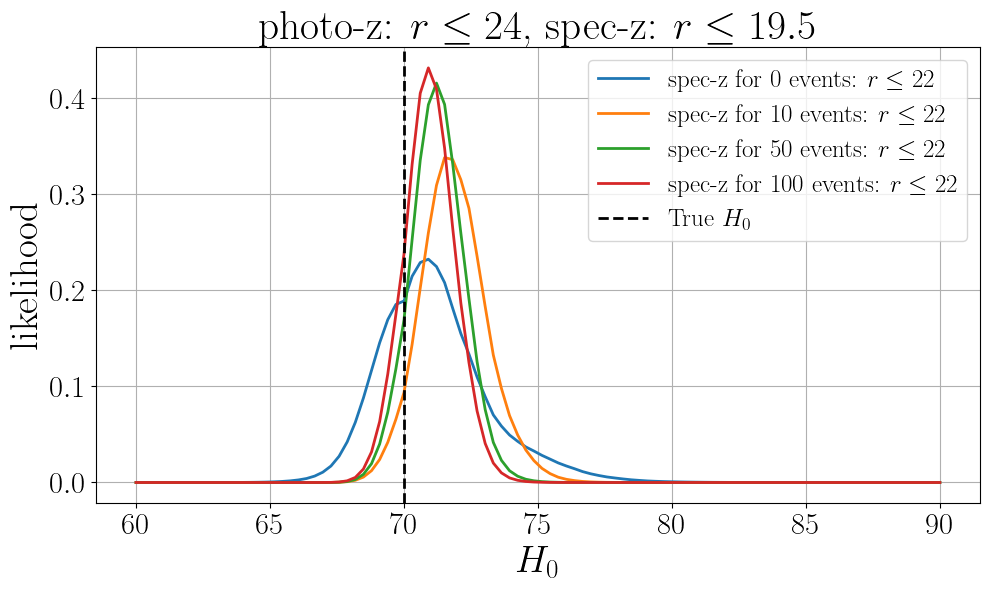

In [5]:
import matplotlib.pyplot as plt

def calculate_fractional_error(H0_true, H0_array, post):
    H0_mean = np.trapz(H0_array * post, H0_array)
    H0_std = np.sqrt(np.trapz((H0_array - H0_mean)**2 * post, H0_array))
    fractional_error = H0_std / H0_true
    return fractional_error

for num_event_follow_up, post_jax in zip(num_follow_up_events_list, post_jax_list):
    print(f"\narea of {num_event_follow_up}: {np.trapz(post_jax, H0)}")
    print(f"Fractional error of {num_event_follow_up}: {calculate_fractional_error(cosmo.H0, H0, post_jax)}")

plt.style.use('~/research/my_plot_style.style')
plt.figure()
for num_event_follow_up, post_jax in zip(num_follow_up_events_list, post_jax_list):
    plt.plot(H0, post_jax, label=rf'spec-z for {num_event_follow_up} events: $r \leq {spec_subaru_thresholds}$', lw=2)
plt.axvline(cosmo.H0, color='black', linestyle='--', label=rf'True $H_0$')
plt.title(rf'photo-z: $r \leq {photo_thresholds}$, spec-z: $r \leq {spec_default_thresholds}$')
plt.xlabel(r'$H_0$')
plt.ylabel('likelihood')
plt.legend()
plt.show()